In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import pandas
from pprint import pprint

In [2]:
with open('./data/datasetsTable2026-6-1.json', 'r') as f:
    js = json.load(f)

####view an example scan data
#pprint(js[293])



##commented keys are mostly constant for all the scans
keys = [
        'scanID', # 102442
        'start time',# '2026-05-28T10:23:38.443620'
        'Sample',
        'description', #position [1-5]
        'Total number frames',# 5|10
        'end time',# '2026-05-28T10:23:38.443620'
        'sams4_x',
        'sams4_y', 
        'title', #timescan 10 0.1 0.0
        
       ]

def extract_scan_info(d):
    out_dir = {}
    if 'comment' in d.keys():
        out_dir['comment_max4'] = d['comment']
    else:
        out_dir['comment_max4'] = ''
    for key in keys:
        if key in d['scientificMetadata'].keys():
            out_dir[key] = d['scientificMetadata'][key]['value']
        else:
            out_dir[key] = ''
    return out_dir

out_list = [out_d for out_d in map(lambda d:extract_scan_info(d), js)]

    


In [3]:
## check which values are unique to see what we can delete
df = pandas.DataFrame(out_list)

df



,comment_max4,scanID,start time,Sample,description,Total number frames,end time,sams4_x,sams4_y,title
0,,103624,2026-05-29T22:53:23.697546,,,1,2026-05-29T22:53:29.101350,116.66355,29.45525,timescan 1 0.1 0.0
1,,103623,2026-05-29T22:53:15.387985,,,1,2026-05-29T22:53:20.135806,116.66355,29.45520,timescan 1 0.1 0.0
2,,103622,2026-05-29T22:52:39.631841,,,1,2026-05-29T22:52:44.118719,116.58500,26.97280,timescan 1 0.1 0.0
3,,103621,2026-05-29T22:52:22.611167,,,1,2026-05-29T22:52:26.338113,116.58500,26.97335,timescan 1 0.1 0.0
4,,103620,2026-05-29T22:52:08.473632,,,1,2026-05-29T22:52:14.094355,116.58500,26.97375,timescan 1 0.1 0.0
...,...,...,...,...,...,...,...,...,...,...
1184,,102437,2026-05-28T08:41:03.368110,,position 1,1,2026-05-28T08:41:08.222247,133.18370,23.83820,timescan 1 0.1 0.0
1185,,102436,2026-05-28T08:36:15.937759,,position 1,1,2026-05-28T08:36:20.290364,133.18370,23.83825,timescan 1 0.1 0.0
1186,,102435,2026-05-28T08:35:21.210892,,position 1,1,2026-05-28T08:35:26.177672,133.18365,23.83820,timescan 1 0.1 0.0
1187,,102434,2026-05-28T08:19:16.676553,,position 1,1,2026-05-28T08:19:23.114464,33.18630,23.83815,timescan 1 0.1 0.0


In [4]:


Y2F_buffer8_runs = [i for i in range(102532, 102628)]
Y2F_aa_runs = [i for i in range(102628, 102726)]
buffer_aa_runs = [i for i in range(102726, 102809)]
capillary1_runs = [i for i in range(102809,102821)]
capillary2_runs = [i for i in range(102821, 102833)]
capillary3_runs = [i for i in range(102833, 102852)]
Y2F_h2o_h2o_runs = [i for i in range(102901, 103021)]
Y2F_h2o_kpi_1_runs = [i for i in range(103021, 103091)]
Y2F_h2o_kpi_2_runs = [i for i in range(103091, 103171)]
Y2F_h2o_kpi_nopump_runs = [i for i in range(103171, 103186)]
kpi_h2o_1_runs = [i for i in range(103186, 103231)]
kpi_h2o_2_runs = [i for i in range(103231, 103326)]
kpi_h2o_3_runs = [i for i in range(103326,103331)]
YR2A_h2o_kpi_runs = [i for i in range(103331, 103376)]
YR2A_h2o_h2o_runs = [i for i in range(103376, 103414)]
Y2F_kpi_h2o_runs = [i for i in range(103414, 103456)]
Y2F_kpi_AcA_1_runs = [i for i in range(103456, 103526)]
Y2F_kpi_AcA_2_runs = [i for i in range(103526, 103609)]
resin_runs = [i for i in range(103609, 103624)]

h2o_runs = [i for i in range(102871, 102901)]



Y2F_runs = Y2F_buffer8_runs + Y2F_aa_runs + Y2F_h2o_h2o_runs + Y2F_h2o_kpi_1_runs \
            + Y2F_h2o_kpi_2_runs + Y2F_h2o_kpi_nopump_runs + Y2F_kpi_h2o_runs \
            + Y2F_kpi_AcA_1_runs + Y2F_kpi_AcA_2_runs


kpi_h2o_runs = kpi_h2o_1_runs+kpi_h2o_2_runs+kpi_h2o_3_runs



def label_sample(scan_ids, sample_name):
    df.loc[df["scanID"].isin(scan_ids), "Sample"] = sample_name


label_sample(Y2F_buffer8_runs, 'Y2F+kpi/kpi')
label_sample(Y2F_aa_runs, 'Y2F+kpi/aa')
label_sample(buffer_aa_runs, 'kpi/aa')
label_sample(Y2F_h2o_h2o_runs, 'Y2F+h2o/h2o')
label_sample(Y2F_h2o_kpi_1_runs+Y2F_h2o_kpi_2_runs+Y2F_h2o_kpi_nopump_runs, 'Y2F+h2o/kpi')
label_sample(kpi_h2o_1_runs+kpi_h2o_2_runs+kpi_h2o_3_runs, 'kpi/h2o')

label_sample(YR2A_h2o_kpi_runs, 'YR2A+h2o/kpi')
label_sample(YR2A_h2o_h2o_runs, 'YR2A+h2o/h2o')

label_sample(Y2F_kpi_h2o_runs, 'Y2F+kpi/h2o')
label_sample(Y2F_kpi_AcA_1_runs+Y2F_kpi_AcA_2_runs, 'Y2F+kpi/aa')

label_sample(capillary1_runs, 'cap1')
label_sample(capillary2_runs, 'cap2')
label_sample(capillary3_runs, 'cap3')

label_sample(h2o_runs, 'h2o/h2o')












In [5]:

df = df.iloc[::-1] #reverse the rows so most recent runs are at the bottom

df.to_csv('./data/scans_clean.csv')

(26.0, 34.0)

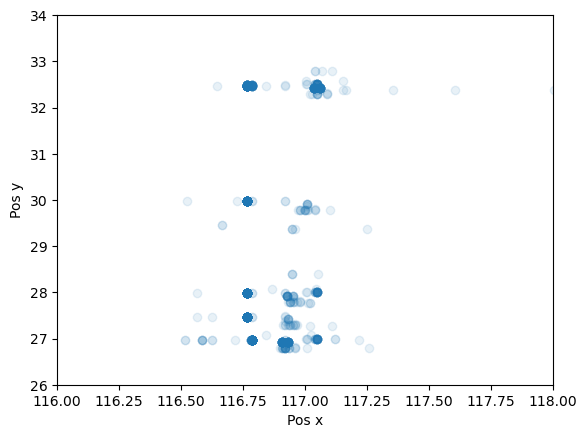

In [6]:
plt.figure()
plt.scatter(df['sams4_x'], df['sams4_y'], alpha=0.1)
plt.xlabel('Pos x')
plt.ylabel('Pos y')
plt.xlim([116, 118])
plt.ylim([26,34])